In [1]:
import sys
sys.path.append('../../scripts')
import utils as util
import stock_indicators as si
import plot as plot

In [2]:
stockutils = util.StockUtils
preprocesser = util.DataPreprocessor

Load the Data.

In [3]:
data = stockutils.load_stock_data('../../data/Stock Data/NVDA.csv')
data.head(5)

,Ticker,Date,Close,High,Low,Open,Volume
0,NVDA,2009-01-02,0.199652,0.201027,0.184294,0.184982,497124000
1,NVDA,2009-01-05,0.203319,0.207904,0.195984,0.197360,705736000
2,NVDA,2009-01-06,0.210196,0.216156,0.204695,0.209279,657904000
3,NVDA,2009-01-07,0.197589,0.205382,0.190483,0.205382,870096000
4,NVDA,2009-01-08,0.192546,0.195067,0.180626,0.195067,1014496000


In [4]:
preprocesser.explore_data(data)

Shape of the data: (3774, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3774 entries, 0 to 3773
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Ticker  3774 non-null   object 
 1   Date    3774 non-null   object 
 2   Close   3774 non-null   float64
 3   High    3774 non-null   float64
 4   Low     3774 non-null   float64
 5   Open    3774 non-null   float64
 6   Volume  3774 non-null   int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 206.5+ KB
Info of the data: None


Reorder the columns and keep the ticker symbol.

In [5]:
data = data[['Ticker', 'Date', 'Open', 'High', 'Low', 'Close', 'Volume']].copy()

In [6]:
stockutils.index_by_date(data)
data.head()

,Ticker,Open,High,Low,Close,Volume
Date,,,,,,
2009-01-02,NVDA,0.184982,0.201027,0.184294,0.199652,497124000
2009-01-05,NVDA,0.197360,0.207904,0.195984,0.203319,705736000
2009-01-06,NVDA,0.209279,0.216156,0.204695,0.210196,657904000
2009-01-07,NVDA,0.205382,0.205382,0.190483,0.197589,870096000
2009-01-08,NVDA,0.195067,0.195067,0.180626,0.192546,1014496000


In [7]:
data.describe()

,Open,High,Low,Close,Volume
count,3774.000000,3774.000000,3774.000000,3774.000000,3.774000e+03
mean,6.793541,6.915713,6.666721,6.796822,5.230753e+08
std,10.659140,10.843532,10.461388,10.659754,3.205760e+08
min,0.165269,0.171228,0.162289,0.165269,4.564400e+07
25%,0.357017,0.362422,0.351743,0.357397,3.188510e+08
50%,1.166935,1.176017,1.157976,1.167304,4.495585e+08
75%,6.939958,7.091671,6.849259,7.018725,6.419770e+08
max,50.182284,50.518225,49.387239,50.379307,3.692928e+09


In [8]:
plotter = plot.Plot

#### Analysis Indicators with TA-Lib

In [9]:
technical_indicators = si.IndicatorCalculator

In [10]:
technical_indicators.calculate_technical_indicators(data)
data.tail(5)

,Ticker,Open,High,Low,Close,Volume,SMA_20,SMA_50,EMA_20,EMA_50,RSI_14,MACD,MACDSignal,MACD_hist
Date,,,,,,,,,,,,,,
2023-12-22,NVDA,49.170342,49.358247,48.442706,48.805527,252507000,47.706983,46.257777,47.706983,46.257777,55.352119,0.634352,0.564438,0.069914
2023-12-26,NVDA,48.943454,49.575137,48.935459,49.254299,244200000,47.759019,46.334178,47.759019,46.334178,57.245971,0.655689,0.582688,0.073001
2023-12-27,NVDA,49.486186,49.655100,49.060397,49.392231,233648000,47.838989,46.400666,47.838989,46.400666,57.837928,0.675937,0.601338,0.074599
2023-12-28,NVDA,49.618126,49.859003,49.387239,49.497185,246587000,47.908266,46.512367,47.908266,46.512367,58.310919,0.692470,0.619564,0.072906
2023-12-29,NVDA,49.788039,49.971949,48.726571,49.497185,389293000,48.046003,46.658888,48.046003,46.658888,58.310919,0.697532,0.635158,0.062374


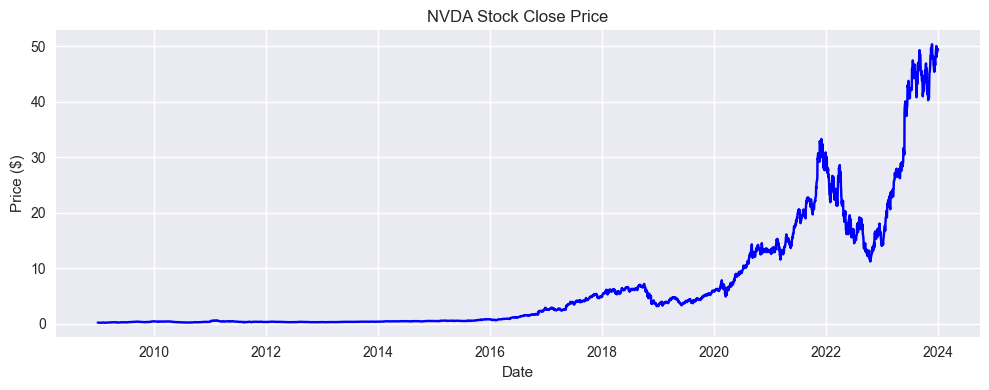

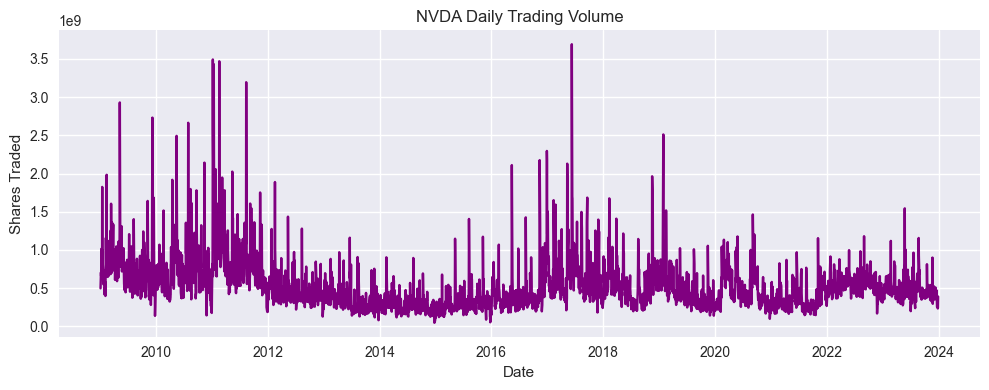

In [11]:
plotter.plot_stock_price(data)

In [12]:
plotter.plot_stock_mva(data)

In [13]:
plotter.plot_ema(data)

In [14]:
plotter.plot_rsi(data)

In [15]:
plotter.plot_macd(data)